# Agent X Focus

Import Libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import Table

import seaborn as sns

## Combined Subgroup:

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Read data

In [59]:
subgroup_theoretical = pd.read_csv("../../data/processed/subgroup_theoretical.csv")

In [60]:
subgroup_theoretical= subgroup_theoretical[subgroup_theoretical["Response_Full"]!= "missing_response"].copy()

1. Contingency Table

In [61]:
contingency = pd.crosstab(
    [subgroup_theoretical["Agent"], subgroup_theoretical["Focus"]],
    subgroup_theoretical["Response_Full"]
)

contingency

Response_Full  L1_transfer  L2_other  correct
Agent Focus                                  
0     I                 26        19       24
      They              31        12       11
1     I                 27         5       16
      They              12         2       10

2. Proportions

In [62]:
proportions = pd.crosstab(
    [subgroup_theoretical["Agent"],subgroup_theoretical["Focus"]],
    subgroup_theoretical["Response_Full"],
    normalize="index"
)

proportions

Response_Full  L1_transfer  L2_other   correct
Agent Focus                                   
0     I           0.376812  0.275362  0.347826
      They        0.574074  0.222222  0.203704
1     I           0.562500  0.104167  0.333333
      They        0.500000  0.083333  0.416667

3. Chi-Square Test

In [63]:
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 12.364
p-value: 0.0543
Degrees of freedom: 6


There is no evidence that response distribution differs across reversibility conditions.

4. Expected Counts

In [64]:
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

expected_df

Response_Full  L1_transfer   L2_other    correct
Agent Focus                                     
0     I          33.969231  13.446154  21.584615
      They       26.584615  10.523077  16.892308
1     I          23.630769   9.353846  15.015385
      They       11.815385   4.676923   7.507692

In [65]:
print(expected_df < 5)

Response_Full  L1_transfer  L2_other  correct
Agent Focus                                  
0     I              False     False    False
      They           False     False    False
1     I              False     False    False
      They           False      True    False


There is a group with fewer than 5 observations.

5. Cramér's V

In [66]:
n = contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.178


V = 0.159: 

6. Standardized Residuals

In [67]:
residuals = (
    contingency - expected
) / np.sqrt(expected)

residuals

Response_Full  L1_transfer  L2_other   correct
Agent Focus                                   
0     I          -1.367331  1.514589  0.519893
      They        0.856354  0.455288 -1.433643
1     I           0.693094 -1.423567  0.254096
      They        0.053709 -1.237815  0.909596

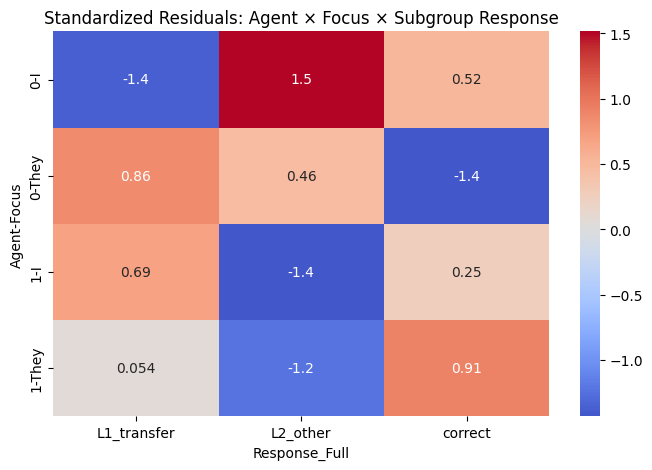

In [68]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Agent × Focus × Subgroup Response")
plt.show()

7. Interpretation

Interpretation:

- χ² significant / not significant
- Effect size
- Cells driving the association

## Goal Behaviour Subgroup:
# Goals

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Split data into goals and no_goals

In [69]:
goals = subgroup_theoretical[subgroup_theoretical["Goal_Type"]!= "no_goal"].copy()

In [70]:
no_goals = subgroup_theoretical[subgroup_theoretical["Goal_Type"]== "no_goal"].copy()

1. Contingency Table

In [71]:
goal_contingency = pd.crosstab(
    [goals["Agent"], goals["Focus"]],
    goals["Response_Full"]
)

goal_contingency

Response_Full  L1_transfer  L2_other  correct
Agent Focus                                  
0     I                 13        16       18
      They              21         7        8
1     I                 18         3       11
      They              10         0        6

2. Proportions

In [72]:
goal_proportions = pd.crosstab(
    [goals["Agent"],goals["Focus"]],
    goals["Response_Full"],
    normalize="index"
)

goal_proportions

Response_Full  L1_transfer  L2_other   correct
Agent Focus                                   
0     I           0.276596  0.340426  0.382979
      They        0.583333  0.194444  0.222222
1     I           0.562500  0.093750  0.343750
      They        0.625000  0.000000  0.375000

3. Chi-Square Test

In [73]:
chi2, p, dof, expected = chi2_contingency(goal_contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 17.590
p-value: 0.0073
Degrees of freedom: 6


4. Expected Counts

In [74]:
goal_expected_df = pd.DataFrame(
    expected,
    index=goal_contingency.index,
    columns=goal_contingency.columns
)

goal_expected_df

Response_Full  L1_transfer  L2_other    correct
Agent Focus                                    
0     I          22.244275  9.328244  15.427481
      They       17.038168  7.145038  11.816794
1     I          15.145038  6.351145  10.503817
      They        7.572519  3.175573   5.251908

In [75]:
print(goal_expected_df < 5)

Response_Full  L1_transfer  L2_other  correct
Agent Focus                                  
0     I              False     False    False
      They           False     False    False
1     I              False     False    False
      They           False      True    False


There are 2 groups with fewer than 5  observations

5. Cramér's V

In [76]:
n = goal_contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(goal_contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.259


V = 0.196: 

6. Standardized Residuals

In [77]:
goal_residuals = (
    goal_contingency - expected
) / np.sqrt(expected)

goal_residuals

Response_Full  L1_transfer  L2_other   correct
Agent Focus                                   
0     I          -1.960035  2.184440  0.654954
      They        0.959809 -0.054260 -1.110322
1     I           0.733610 -1.329741  0.153098
      They        0.882136 -1.782014  0.326435

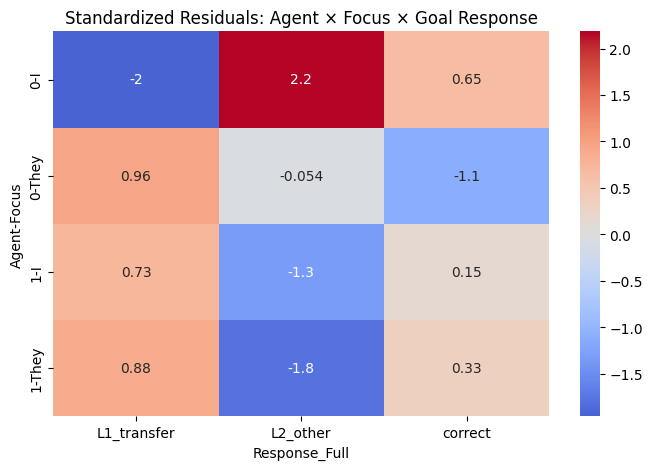

In [78]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    goal_residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Agent × Focus × Goal Response")
plt.show()

7. Interpretation

Interpretation:

- χ² significant / not significant
- Effect size
- Cells driving the association

## Goal Behaviour Subgroup:
# No Goals

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

1. Contigency Table

In [79]:
no_goal_contingency = pd.crosstab(
    [no_goals["Agent"], no_goals["Focus"]],
    no_goals["Response_Full"]
)

no_goal_contingency

Response_Full  L1_transfer  L2_other  correct
Agent Focus                                  
0     I                 13         3        6
      They              10         5        3
1     I                  9         2        5
      They               2         2        4

2. Proportions

In [80]:
no_goal_proportions = pd.crosstab(
    [no_goals["Agent"],no_goals["Focus"]],
    no_goals["Response_Full"],
    normalize="index"
)

no_goal_proportions

Response_Full  L1_transfer  L2_other   correct
Agent Focus                                   
0     I           0.590909  0.136364  0.272727
      They        0.555556  0.277778  0.166667
1     I           0.562500  0.125000  0.312500
      They        0.250000  0.250000  0.500000

3. Chi-Square Test

In [81]:
chi2, p, dof, expected = chi2_contingency(no_goal_contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 5.240
p-value: 0.5134
Degrees of freedom: 6


4. Expected Counts

In [82]:
no_goal_expected_df = pd.DataFrame(
    expected,
    index=no_goal_contingency.index,
    columns=no_goal_contingency.columns
)

no_goal_expected_df

Response_Full  L1_transfer  L2_other  correct
Agent Focus                                  
0     I            11.6875     4.125   6.1875
      They          9.5625     3.375   5.0625
1     I             8.5000     3.000   4.5000
      They          4.2500     1.500   2.2500

In [83]:
print(no_goal_expected_df < 5)

Response_Full  L1_transfer  L2_other  correct
Agent Focus                                  
0     I              False      True    False
      They           False      True    False
1     I              False      True     True
      They            True      True     True


5. Cramér's V

In [84]:
n = no_goal_contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(no_goal_contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.202


6. Standardized Residuals

In [85]:
no_goal_residuals = (
    no_goal_contingency - expected
) / np.sqrt(expected)

no_goal_residuals

Response_Full  L1_transfer  L2_other   correct
Agent Focus                                   
0     I           0.383918 -0.553912 -0.075378
      They        0.141479  0.884538 -0.916667
1     I           0.171499 -0.577350  0.235702
      They       -1.091410  0.408248  1.166667

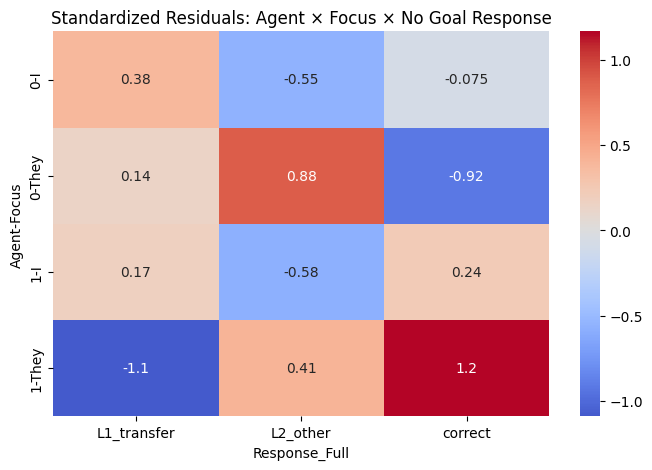

In [86]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    no_goal_residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Agent × Focus × No Goal Response")
plt.show()

7. Interpretation

Interpretation:

- χ² significant / not significant
- Effect size
- Cells driving the association